# GCGA Genetic Algorithm 진행 추이 시각화

`../03_gcga/gcga.db` 의 ASE database 로부터 부모/자식 세대 에너지 정보를 읽어 GA 의 진행 추이를 그립니다.

- **kid index (generation)** : 자식이 생성된 순서 (`s00XXXX` 의 번호)
- **eV** : potential energy
- **grandPot** : grand potential (GCGA 의 fitness 기준)

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import scienceplots
import lovelyplots

from ase.db import connect

# 1. 전역 스타일 테마 적용
plt.style.use(["science", "notebook"])
# plt.style.use(['ipynb','colorsblind34'])

# 2. 전역 파라미터 통합 설정
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.family': 'Arial',
    # 'font.size': 18,
    # 'axes.labelsize': 20,
    # 'axes.titlesize': 22,
    # 'xtick.labelsize': 18,
    # 'ytick.labelsize': 18,
    # 'xtick.major.size': 8,
    # 'ytick.major.size': 8,
    # 'xtick.minor.size': 4,
    # 'ytick.minor.size': 4,
    # 'legend.fontsize': 18,
    # 'legend.frameon': True,
    # 'lines.linewidth': 3.5,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})
print('✅ Matplotlib 전역 스타일 통일 설정 완료!')

✅ Matplotlib 전역 스타일 통일 설정 완료!


In [2]:
# --- DB 로드 ---
DB_PATH = '../03_gcga/process/gcga.db'
FIG_DIR = './figures'
os.makedirs(FIG_DIR, exist_ok=True)

db = connect(DB_PATH)

# parent / kid 정보를 한 번의 순회로 모두 수집
# (kid_E, kid_natoms 등이 항상 같은 db snapshot에서 나오도록 보장)
parent_E, parent_GP, parent_natoms = [], [], []
kid_idx, kid_E, kid_GP, kid_natoms = [], [], [], []

for row in db.select():
    name = row.name
    if name.startswith('parent'):
        parent_E.append(row.eV)
        parent_GP.append(row.grandPot)
        parent_natoms.append(row.natoms)
    elif name.startswith('s') and name[1:].isdigit():
        kid_idx.append(int(name[1:]))
        kid_E.append(row.eV)
        kid_GP.append(row.grandPot)
        kid_natoms.append(row.natoms)

parent_E      = np.asarray(parent_E)
parent_GP     = np.asarray(parent_GP)
parent_natoms = np.asarray(parent_natoms)

# kid 는 생성순으로 정렬
order = np.argsort(kid_idx)
kid_idx    = np.asarray(kid_idx)[order]
kid_E      = np.asarray(kid_E)[order]
kid_GP     = np.asarray(kid_GP)[order]
kid_natoms = np.asarray(kid_natoms)[order]

# 누적 최저 에너지 (parent 까지 포함한 전체 최저값을 기준으로)
init_min_E  = parent_E.min()
init_min_GP = parent_GP.min()
cum_min_E   = np.minimum.accumulate(np.concatenate([[init_min_E],  kid_E ]))[1:]
cum_min_GP  = np.minimum.accumulate(np.concatenate([[init_min_GP], kid_GP]))[1:]

print(f'부모 개수 : {len(parent_E)}')
print(f'자식 개수 : {len(kid_E)}')
print(f'부모 최저 E   : {parent_E.min():.3f} eV')
print(f'자식 최저 E   : {kid_E.min():.3f} eV')
print(f'부모 최저 GP  : {parent_GP.min():.3f} eV')
print(f'자식 최저 GP  : {kid_GP.min():.3f} eV')
print(f'부모 원자 수  : {parent_natoms.min()} ~ {parent_natoms.max()}')
print(f'자식 원자 수  : {kid_natoms.min()} ~ {kid_natoms.max()}')

부모 개수 : 50
자식 개수 : 342
부모 최저 E   : -3933.721 eV
자식 최저 E   : -4446.508 eV
부모 최저 GP  : -102.728 eV
자식 최저 GP  : -232.040 eV
부모 원자 수  : 1536 ~ 1536
자식 원자 수  : 1424 ~ 1720


## 1. 세대에 따른 에너지 변화

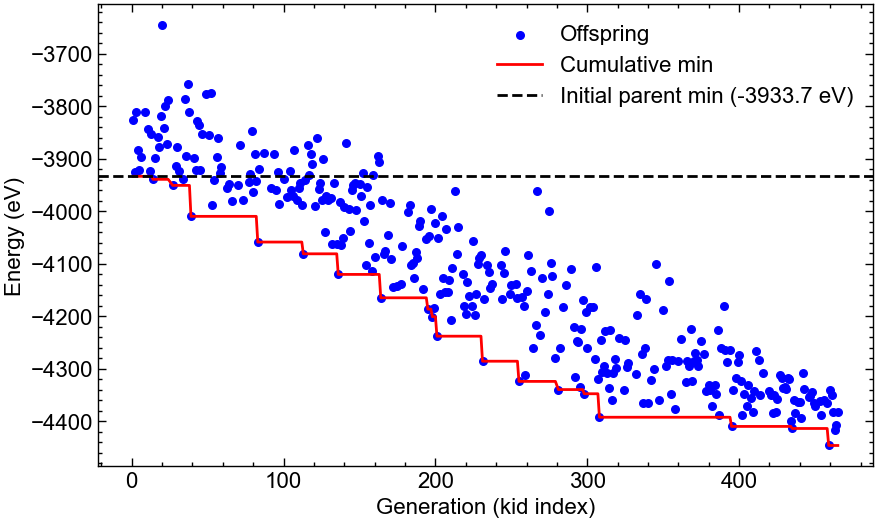

In [3]:
fig, ax = plt.subplots()

ax.scatter(kid_idx, kid_E, s=30, color='blue', label='Offspring') #alpha=0.6 edgecolor='none',
ax.plot(kid_idx, cum_min_E, color='red', label='Cumulative min')
ax.axhline(parent_E.min(), color='k', ls='--', label=f'Initial parent min ({parent_E.min():.1f} eV)')

ax.set_xlabel('Generation (kid index)')
ax.set_ylabel('Energy (eV)')
# ax.set_title('Energy vs. Generation')
ax.legend(loc='upper right')#, fontsize=14)
# ax.minorticks_on()
# ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.savefig(os.path.join(FIG_DIR, '01_energy_vs_generation.png'))
plt.show()

## 2. 부모세대 vs 자식세대 에너지 분포

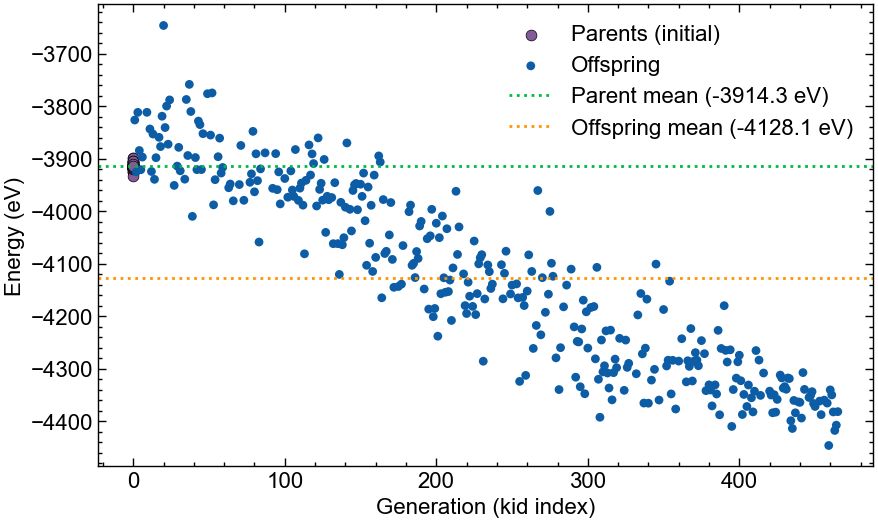

In [4]:
fig, ax = plt.subplots()

# 부모 : x = 0 영역에 산점
parent_x = np.zeros_like(parent_E)
ax.scatter(parent_x, parent_E,
           s=60, color='C4',
           edgecolor='k', linewidth=0.5, label='Parents (initial)')

# 자식 : 실제 생성 순서대로
ax.scatter(kid_idx, kid_E,
           s=40, color='C0',
           edgecolor='none', label='Offspring')

# 부모/자식 평균 라인
ax.axhline(parent_E.mean(), color='C1', ls=':', lw=2,
           label=f'Parent mean ({parent_E.mean():.1f} eV)')
ax.axhline(kid_E.mean(), color='C2', ls=':', lw=2,
           label=f'Offspring mean ({kid_E.mean():.1f} eV)')

ax.set_xlabel('Generation (kid index)')
ax.set_ylabel('Energy (eV)')
# ax.set_title('Parents vs. Offspring')
ax.legend(loc='upper right')#, fontsize=13)
ax.minorticks_on()

plt.savefig(os.path.join(FIG_DIR, '02_parents_vs_offspring.png'))
plt.show()

## 3. Total minimum energy

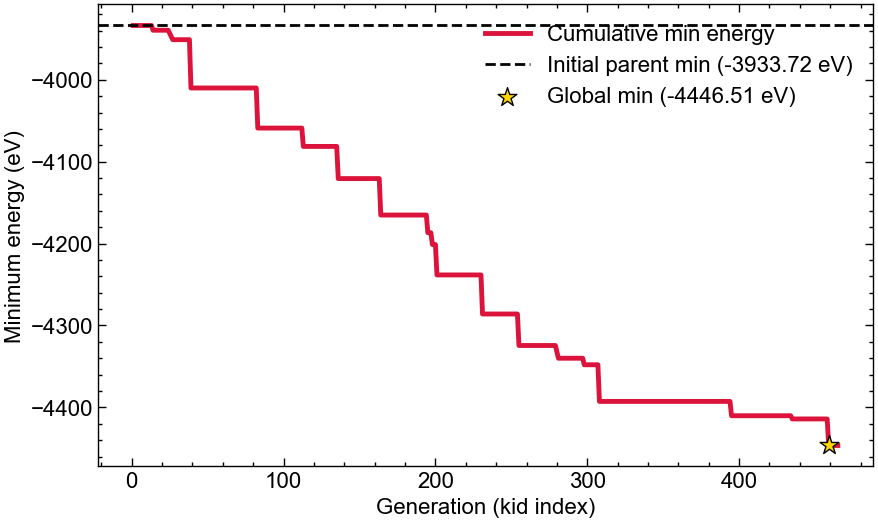

In [5]:
fig, ax = plt.subplots()

ax.plot(kid_idx, cum_min_E,
        color='crimson', lw=3.5, label='Cumulative min energy')
ax.axhline(parent_E.min(), color='k', ls='--', lw=2,
           label=f'Initial parent min ({parent_E.min():.2f} eV)')
ax.scatter([kid_idx[np.argmin(kid_E)]], [kid_E.min()],
           s=200, marker='*', color='gold', edgecolor='k',
           zorder=5, label=f'Global min ({kid_E.min():.2f} eV)')

ax.set_xlabel('Generation (kid index)')
ax.set_ylabel('Minimum energy (eV)')
# ax.set_title('Total Minimum Energy Progression')
ax.legend(loc='upper right')#, fontsize=13)
ax.minorticks_on()

plt.savefig(os.path.join(FIG_DIR, '03_total_min_energy.png'))
plt.show()

## 4. (선택) Grand Potential 기준 동일 플롯

GCGA 의 자연 선택은 `grandPot` 을 기준으로 이루어지므로, 동일한 시각화를 GP 기준으로 한 번 더 그립니다.

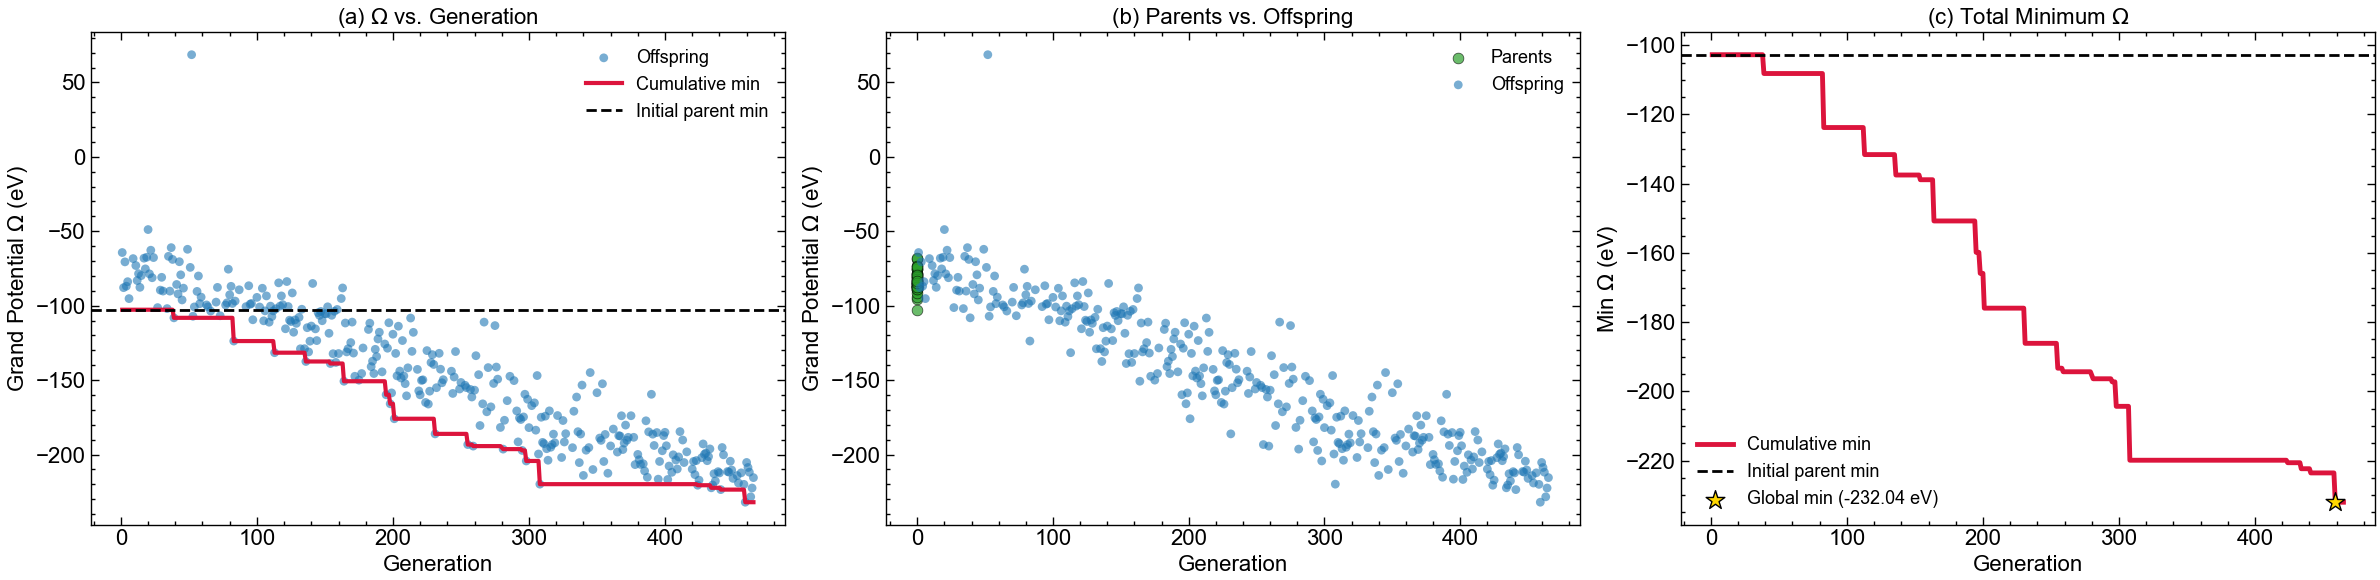

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# (a) GP vs generation
ax = axes[0]
ax.scatter(kid_idx, kid_GP, s=40, color='#1f77b4', alpha=0.6,
           edgecolor='none', label='Offspring')
ax.plot(kid_idx, cum_min_GP, color='crimson', lw=3.0, label='Cumulative min')
ax.axhline(parent_GP.min(), color='k', ls='--', lw=2, label='Initial parent min')
ax.set_xlabel('Generation')
ax.set_ylabel(r'Grand Potential $\Omega$ (eV)')
ax.set_title('(a) $\\Omega$ vs. Generation')
ax.legend(fontsize=13)
ax.minorticks_on()

# (b) Parent vs Kid
ax = axes[1]
ax.scatter(np.zeros_like(parent_GP), parent_GP, s=60, color='#2ca02c',
           alpha=0.7, edgecolor='k', linewidth=0.5, label='Parents')
ax.scatter(kid_idx, kid_GP, s=40, color='#1f77b4', alpha=0.6,
           edgecolor='none', label='Offspring')
ax.set_xlabel('Generation')
ax.set_ylabel(r'Grand Potential $\Omega$ (eV)')
ax.set_title('(b) Parents vs. Offspring')
ax.legend(fontsize=13)
ax.minorticks_on()

# (c) Cumulative min GP
ax = axes[2]
ax.plot(kid_idx, cum_min_GP, color='crimson', lw=3.5, label='Cumulative min')
ax.axhline(parent_GP.min(), color='k', ls='--', lw=2, label='Initial parent min')
ax.scatter([kid_idx[np.argmin(kid_GP)]], [kid_GP.min()], s=200, marker='*',
           color='gold', edgecolor='k', zorder=5,
           label=f'Global min ({kid_GP.min():.2f} eV)')
ax.set_xlabel('Generation')
ax.set_ylabel(r'Min $\Omega$ (eV)')
ax.set_title('(c) Total Minimum $\\Omega$')
ax.legend(fontsize=13)
ax.minorticks_on()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '04_grandPot_summary.png'))
plt.show()

## 5. 세대별 최저 에너지 + 원자 수 동시 추적

GCGA 는 grand canonical 이라 자식 세대마다 구조의 총 원자 수가 가변적입니다 (현재 시스템: Ag 단일 원소).
- **왼쪽 축 (line)** : 누적 최저 에너지 — global optimization 의 수렴 추이
- **오른쪽 축 (point)** : 각 세대 자식 구조의 원자 수
- 점선 : 초기 parent 의 원자 수 (모두 동일하므로 단일 reference 값)

Parent 원자 수     : 1536
Kid 원자 수 범위   : 1424 ~ 1720
Kid 평균/중앙값    : 1607.8 / 1611


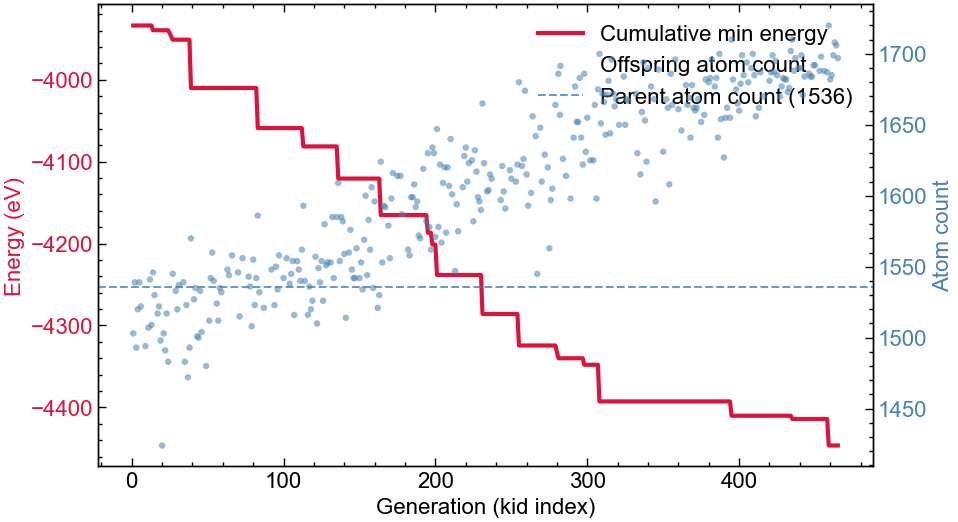

In [7]:
# load-db 에서 이미 수집한 kid_natoms, parent_natoms 를 그대로 사용
parent_N = int(np.unique(parent_natoms)[0])  # parent 는 모두 동일

print(f'Parent 원자 수     : {parent_N}')
print(f'Kid 원자 수 범위   : {kid_natoms.min()} ~ {kid_natoms.max()}')
print(f'Kid 평균/중앙값    : {kid_natoms.mean():.1f} / {np.median(kid_natoms):.0f}')

# --- 이중 y축 플롯 ---
fig, ax1 = plt.subplots()

c_E = 'crimson'
c_N = 'steelblue'

# Left: 누적 최저 에너지 (line)
ax1.plot(kid_idx, cum_min_E, color=c_E, lw=3.0, label='Cumulative min energy')
ax1.set_xlabel('Generation (kid index)')
ax1.set_ylabel('Energy (eV)', color=c_E)
ax1.tick_params(axis='y', labelcolor=c_E)
ax1.minorticks_on()

# Right: 자식 구조 원자 수 (point) + parent reference
ax2 = ax1.twinx()
ax2.scatter(kid_idx, kid_natoms,
            s=22, color=c_N, edgecolor='none', alpha=0.55,
            label='Offspring atom count')
ax2.axhline(parent_N, color=c_N, ls='--', lw=1.5, alpha=0.8,
            label=f'Parent atom count ({parent_N})')
ax2.set_ylabel('Atom count', color=c_N)
ax2.tick_params(axis='y', labelcolor=c_N)

# 범례 통합
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='best')

plt.savefig(os.path.join(FIG_DIR, '05_energy_and_atomcount.png'))
plt.show()

## 6. 최저 에너지 갱신 구조만 추적

global optimization 의 "마일스톤" — 누적 최저 에너지를 실제로 갱신한 구조들만 골라
- **왼쪽 축 (line + marker)** : 그 구조의 에너지 (단조 감소)
- **오른쪽 축 (point)** : 그 구조의 원자 수

시작점은 초기 parent 중 가장 낮은 에너지를 가진 구조입니다.

최저 에너지 갱신 횟수 : 18
시작점 (parent best)  : E=-3933.721 eV, N=1536
  gen=  14   E=-3939.509 eV   N=1546
  gen=  27   E=-3951.044 eV   N=1545
  gen=  39   E=-4010.015 eV   N=1570
  gen=  83   E=-4058.968 eV   N=1586
  gen= 113   E=-4081.376 eV   N=1593
  gen= 136   E=-4120.626 eV   N=1609
  gen= 164   E=-4165.163 eV   N=1624
  gen= 195   E=-4186.738 eV   N=1630
  gen= 198   E=-4201.142 eV   N=1634
  gen= 201   E=-4238.295 eV   N=1647
  gen= 231   E=-4285.971 eV   N=1665
  gen= 255   E=-4324.418 eV   N=1680
  gen= 281   E=-4339.978 eV   N=1686
  gen= 298   E=-4347.943 eV   N=1686
  gen= 308   E=-4392.696 eV   N=1700
  gen= 395   E=-4410.186 eV   N=1710
  gen= 435   E=-4414.101 eV   N=1710
  gen= 459   E=-4446.508 eV   N=1720


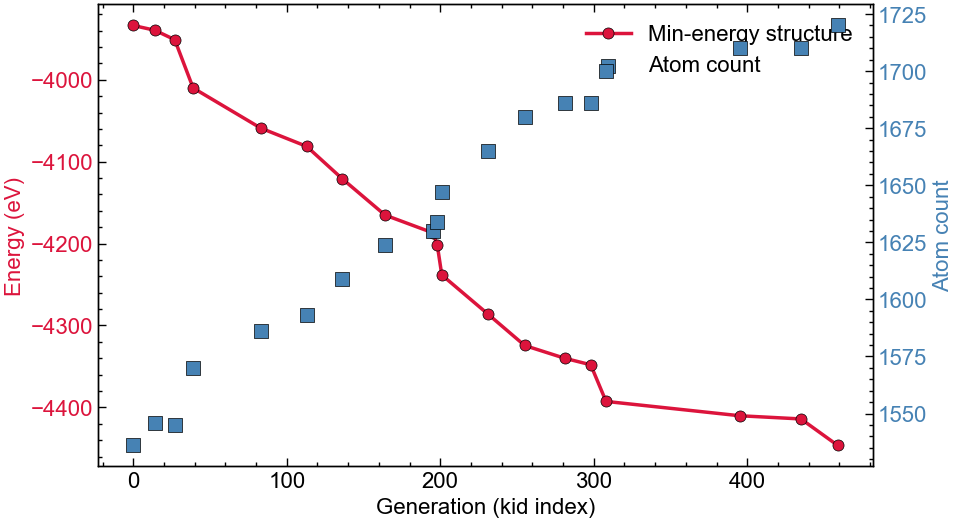

In [8]:
# --- 누적 최저 에너지를 '갱신'한 자식 인덱스 추출 ---
init_E_argmin = int(np.argmin(parent_E))
init_E_min    = parent_E[init_E_argmin]
init_N_ref    = int(parent_natoms[init_E_argmin])  # 가장 낮은 E parent 의 원자 수

running_min = init_E_min
mask_imp = np.zeros(len(kid_E), dtype=bool)
for i, E in enumerate(kid_E):
    if E < running_min:
        mask_imp[i] = True
        running_min = E

imp_idx = kid_idx[mask_imp]
imp_E   = kid_E[mask_imp]
imp_N   = kid_natoms[mask_imp]

# 초기 parent (가장 낮은 E) 를 시작점으로 prepend
trk_x = np.concatenate([[0],          imp_idx])
trk_E = np.concatenate([[init_E_min], imp_E])
trk_N = np.concatenate([[init_N_ref], imp_N])

print(f'최저 에너지 갱신 횟수 : {mask_imp.sum()}')
print(f'시작점 (parent best)  : E={init_E_min:.3f} eV, N={init_N_ref}')
for x, e, n in zip(imp_idx, imp_E, imp_N):
    print(f'  gen={x:>4d}   E={e:.3f} eV   N={n}')

# --- 이중 y축 플롯 ---
fig, ax1 = plt.subplots()
c_E = 'crimson'
c_N = 'steelblue'

# Left: 갱신 구조의 에너지 (line + marker)
ax1.plot(trk_x, trk_E, color=c_E, lw=2.5,
         marker='o', ms=8, mec='k', mew=0.5,
         label='Min-energy structure')
ax1.set_xlabel('Generation (kid index)')
ax1.set_ylabel('Energy (eV)', color=c_E)
ax1.tick_params(axis='y', labelcolor=c_E)
ax1.minorticks_on()

# Right: 갱신 구조의 원자 수 (point)
ax2 = ax1.twinx()
ax2.scatter(trk_x, trk_N, s=90, color=c_N, edgecolor='k', linewidth=0.5,
            marker='s', zorder=4, label='Atom count')
ax2.set_ylabel('Atom count', color=c_N)
ax2.tick_params(axis='y', labelcolor=c_N)

# 범례 통합
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='best')

plt.savefig(os.path.join(FIG_DIR, '06_min_energy_structure_track.png'))
plt.show()

## 7. 최저 에너지 갱신 구조 직접 시각화

§6 에서 찾은 갱신 마일스톤 구조들을 별도 파일로 저장하지 않고 nglview 로 바로 본다.
- 인덱스 0 (frame 1) : 초기 best parent
- 이후 frame : 각 자식 갱신 시점 (생성 순)
- Ball size 슬라이더는 ASE 기본 0.5 대신 1.0 으로 초기화

In [9]:
from ase.visualize import view

# --- 갱신 구조의 Atoms 객체를 db 한 번 순회로 수집 ---
imp_idx_set = set(int(x) for x in imp_idx)
parent_pool = []         # [(E, Atoms), ...]
kid_pool    = {}         # {idx: Atoms}

for row in db.select():
    name = row.name
    if name.startswith('parent'):
        parent_pool.append((row.eV, row.toatoms()))
    elif name.startswith('s') and name[1:].isdigit():
        i = int(name[1:])
        if i in imp_idx_set:
            kid_pool[i] = row.toatoms()

best_parent_atoms = min(parent_pool, key=lambda t: t[0])[1]
milestone_atoms = [best_parent_atoms] + [kid_pool[int(i)] for i in imp_idx]

print(f'시각화 대상 구조 수 : {len(milestone_atoms)}  '
      f'(best parent 1 + 자식 갱신 {len(imp_idx)})')
for k, (a, E, N) in enumerate(zip(milestone_atoms, trk_E, trk_N)):
    tag = 'parent best' if k == 0 else f'kid s{int(trk_x[k]):06d}'
    print(f'  frame {k:>2d}  ({tag})   E={E:.3f} eV   N={N}   ({a.get_chemical_formula()})')

# --- nglview ---
gui = view(milestone_atoms, viewer='ngl')
ball_size_slider = next(
    w for w in gui.control_box.children
    if getattr(w, 'description', '') == 'Ball size'
)
ball_size_slider.value = 1.0   # 기본 0.5 → 1.0
gui

시각화 대상 구조 수 : 19  (best parent 1 + 자식 갱신 18)
  frame  0  (parent best)   E=-3933.721 eV   N=1536   (Ag1536)
  frame  1  (kid s000014)   E=-3939.509 eV   N=1546   (Ag1546)
  frame  2  (kid s000027)   E=-3951.044 eV   N=1545   (Ag1545)
  frame  3  (kid s000039)   E=-4010.015 eV   N=1570   (Ag1570)
  frame  4  (kid s000083)   E=-4058.968 eV   N=1586   (Ag1586)
  frame  5  (kid s000113)   E=-4081.376 eV   N=1593   (Ag1593)
  frame  6  (kid s000136)   E=-4120.626 eV   N=1609   (Ag1609)
  frame  7  (kid s000164)   E=-4165.163 eV   N=1624   (Ag1624)
  frame  8  (kid s000195)   E=-4186.738 eV   N=1630   (Ag1630)
  frame  9  (kid s000198)   E=-4201.142 eV   N=1634   (Ag1634)
  frame 10  (kid s000201)   E=-4238.295 eV   N=1647   (Ag1647)
  frame 11  (kid s000231)   E=-4285.971 eV   N=1665   (Ag1665)
  frame 12  (kid s000255)   E=-4324.418 eV   N=1680   (Ag1680)
  frame 13  (kid s000281)   E=-4339.978 eV   N=1686   (Ag1686)
  frame 14  (kid s000298)   E=-4347.943 eV   N=1686   (Ag1686)
  frame 15